<center><a href="https://msu.ai/"><img src="https://edunet.kea.su/repo/EduNet-content/dev-2.4/msu_ai.png" width="1024"></a></center>

<font size="6">Трансформеры</font>

Порождение выходной последовательности по входной находит применение во многих областях машинного обучения: от обработки естественного языка до генерации описаний объектов на фотографиях.

До недавнего времени наиболее эффективные seq2seq-модели основывались на сложных рекуррентных или сверточных нейронных сетях, беря за основу подход encoder-decoder и механизм внимания. В 2017 году в статье [«Attention Is All You Need» 🎓[arxiv]](https://arxiv.org/abs/1706.03762) была предложена новая архитектура, основанная исключительно на механизмах внимания, названная Transformer.

# Классический seq2seq

В простейшем варианте модель seq2seq представляет собой две последовательно соединенные рекуррентные сети: **Кодировщик** и **Декодировщик**. Кодировщик принимает на вход последовательность векторных представлений токенов и генерирует **скрытое состояние** (hidden state), которое подается на вход Декодировщика. Декодировщик, в свою очередь, служит для построения целевой последовательности по внутреннему состоянию.

На примере задачи перевода: на вход кодировщику подается текст на исходном языке. Тогда скрытое состояние можно интерпретировать как смысл этого текста, по которому затем декодировщик восстанавливает текст на целевом языке.

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.4/L10/out/seq_to_seq_with_rnn.png" width="1000"></center>

Было бы здорово так кодировать данные, чтобы сжатые представления на английском языке были близки к сжатым представлениями на русском.

А ещё хорошо бы добиться того, чтобы сжатые представления перестали быть равнозначными. Чтобы учитывались контекст, окружающие слова. Так, для слова "love" гораздо важнее "любовь", нежели "каждому".

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.4/L10/out/attention_vector.png" width="700"></center>

<center><em>Source: <a href="https://teksands.ai/blog/attention-mechanism">Attention Mechanism</a></em></center>

Кроме того, вектор фиксированного размера $h_N$ — бутылочное горлышко сети.

**Идея:** поставить нейросеть поверх $h_1 ... h_4$, чтобы вектор в декодировщик шёл как взвешенная комбинация векторов.

# Cross-Attention

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L10/cross_attention.png" width="700"></center>

<center><em>Source: <a href="https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html">Lena Voita</a></em></center>

Концепция **механизма внимания** (Attention) состоит в предположении, что между токенами существуют некоторые взаимосвязи. При таком подходе кодировщик передает в декодировщик не одно состояние, кодирующее всю последовательность целиком, а взвешенный набор состояний всех токенов.

## RNN + Cross-Attention

В прошлой лекции мы работали с RNN без внимания. С помощью механизма внимания в конце этого блока мы получим примерно следующее:

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L10/cross_attention_with_rnn.png" width="700"></center>

<center><em>Source: <a href="https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html">Lena Voita</a></em></center>

Материал на основе [официальной документации PyTorch 🛠️[doc]](https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html).

### Загрузка и предобработка данных

Мы убрали этапы предобработки данных в отдельный файл, чтобы сконцентрироваться на основных моментах архитектуры решения:

In [ ]:
from IPython.display import clear_output

!pip install -q transformers==4.44.2
!pip install -qU accelerate git+https://github.com/huggingface/peft.git
!pip install -q sentencepiece sentence_transformers
!pip install -q -U datasets huggingface-hub
!pip install -q lightning tbparse
clear_output()

In [ ]:
# Code for sequence to sequence translation
!wget -qN https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L10/s2s.py

Загрузим данные:

In [ ]:
# Source: https://www.manythings.org/anki/
!wget -q https://edunet.kea.su/repo/EduNet-web_dependencies/datasets/eng_rus_vocab.txt

**Подготовка данных**

Предобработка включает преобразование текста из Unicode в ASCII, перевод в нижний регистр и очистку от знаков препинания, апострофов, удаление предложений длинее 10 слов. В итоге получаем пары предложений на английском и русском языках.

Для обучения для каждой пары нам понадобятся входной тензор (индексы слов во входном предложении) и целевой тензор (индексы слов в целевом предложении). При создании этих векторов мы добавим токен EOS к обеим последовательностям.

In [ ]:
import random
from s2s import prepareData

SOS_token = 0
EOS_token = 1
max_length = 10

input_lang, output_lang, pairs = prepareData("eng", "rus", False)
print(random.choice(pairs))

Reading lines...
Read 496059 sentence pairs
Trimmed to 30724 sentence pairs
Counting words...
Counted words:
eng 10510
rus 4349
('они сеичас обедают в столовои', 'they re eating dinner now in the dining room')


Получены два словаря и набор пар строк.
Определим структуру модели.

### Кодировщик

In [ ]:
import torch
import torch.nn as nn

device = # Write your code here


class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = # Write your code here

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = # Write your code here

    def forward(self, input):
        embedded = # Write your code here
        output, hidden = # Write your code here
        return output, hidden

### Слой Attention

Сначала мы вычисляем **набор весов внимания кодировщика**. Они будут умножены на выходные векторы кодировщика для создания взвешенной комбинации. Результат должен содержать информацию об этой конкретной части входной последовательности и помогать декодировщику выбирать правильные выходные слова.

Механизм **аддитивного внимания** реализован в:

[[arxiv] 🎓 Neural Machine Translation by Jointly Learning to Align and Translate (Bandanau et al., 2016)](https://arxiv.org/abs/1409.0473)

$\large a(h, h') = \color{red}{w}^T\tanh(\color{red}{U}h + \color{red}{V}h')$ — аддитивное внимание с $\color{red}{w, U, V}$.

$h$ — **все** скрытые состояния кодировшика, $h'$ — **одно** скрытое состояние декодировщика для конкретного токена.  $\color{red}{w, U, V}$ — обучаемые слои.

В оригинальной статье вектора $h$ и $h'$ конкатенируются, т.е. операция выше представляется как:

$\large a(h, h') = \color{red}{w}^T\tanh(\color{red}{\Omega}[h;h'])$

**Разновидности функций сходства**


$\large a(h, h') = h^Th'$ — скалярное произведение (векторы близких слов практически параллельны);

$\large a(h, h') = \mu * \exp(h^Th')$ — возможны степенные операции, добавление домножения на константу;

$\large a(h, h') = h^T\color{red}{W}h'$ — c матрицей обучаемых параметров $\color{red}{W}$;


Вводя внимание, мы говорили о некоторой **функции сходства** между **текущим** скрытым состоянием декодировщика $h'$ и **всеми** скрытыми состояниями кодировщика $h$. Обобщением механизма внимания является введение  **обучаемых параметров**.

Какие вообще бывают функции сходства?


1.   Первое, что приходит в голову, — просто считать скалярное произведение $h$ и $h'$.
2.   Также можно использовать степенную функцию или умножение на константу.

Первые два способа возможны, только если потребовать, чтобы $h$ и $h'$ имели одинаковую размерность.

3.   Можно вводить матрицу обучаемых параметров $W$.
4.   Можно вводить небольшую двухслойную нейронную сеть с несколькими весовыми матрицами. Такое введение функции сходства называется аддитивным вниманием.



**Добавление слоя внимания в декодировщик**

На каждом этапе декодирования декодеровщику предоставляются входной токен и скрытое состояние. Начальный входной токен — токен начала строки <SOS>, первое скрытое состояние — вектор контекста (последнее скрытое состояние кодировщика).

In [ ]:
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = # Write your code here
        self.Ua = # Write your code here
        self.Va = # Write your code here

    def forward(self, query, keys):
        scores = s# Write your code here
        scores = scores.squeeze(2).unsqueeze(1)

        weights = # Write your code here
        context = # Write your code here #batch matrix-matrix product

        return context, scores


class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = # Write your code here
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = # Write your code here
        self.dropout = # Write your code here

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(
            batch_size, 1, dtype=torch.long, device=device
        ).fill_(SOS_token)
        decoder_hidden = # Write your code here
        decoder_outputs = []
        attentions = []

        for i in range(max_length):
            decoder_output, decoder_hidden, attn_weights = # Write your code here
            decoder_outputs.append(# Write your code here)
            attentions.append(# Write your code here)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1)  # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = # Write your code here
                decoder_input = topi.squeeze(
                    -1
                ).detach()  # detach from history as input

        decoder_outputs = # Write your code here
        decoder_outputs = # Write your code here
        attentions = # Write your code here

        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(# Write your code here)

        query = hidden.permute(1, 0, 2)
        context, attn_weights = # Write your code here
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = # Write your code here
        output = # Write your code here

        return output, hidden, attn_weights

### Обучение модели

Для обучения мы пропускаем предложение через кодировщик и отслеживаем каждый выход и последнее скрытое состояние. Затем декодер получает токен <SOS> в качестве первого входа и последнее скрытое состояние кодировщика в качестве первого скрытого состояния.

**Процесс обучения**:

In [ ]:
from s2s import get_dataloaders

hidden_size = 512
batch_size = 256

(
    input_lang,
    output_lang,
    train_dataloader,
    val_dataloader,
    test_dataloader,
    test_pair_ids,
) = get_dataloaders(batch_size)

encoder = # Write your code here
decoder = # Write your code here

Reading lines...
Read 496059 sentence pairs
Trimmed to 30724 sentence pairs
Counting words...
Counted words:
eng 10510
rus 4349


Процесс обучения занимает примерно 8 минут на GPU. В целях экономии времени и вычислительных ресурсов закомментируем эту часть кода и загрузим предварительно сохраненные логи обучения.

Для запуска обучения необходимо раскомментировать соответствующую строчку в коде и закомментировать загрузку предварительно сохраненных логов.

In [ ]:
import lightning as L

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from s2s import Seq2SeqPipeline


L.seed_everything(42)

checkpoint_callback = ModelCheckpoint(monitor="Loss/val", mode="min", filename="best")

exp_name = f"baseline"
trainer = Trainer(
    max_epochs=80,
    logger=TensorBoardLogger(save_dir=f"logs/seq2seq", name=exp_name),
    num_sanity_val_steps=1,
    callbacks=[checkpoint_callback],
    log_every_n_steps=5,
)


pipeline = # Write your code here

# trainer.fit(
#     model=pipeline,
#     train_dataloaders=train_dataloader,
#     val_dataloaders=val_dataloader,
# )

INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU

Загрузка предварительно сохраненных логов обучения:

In [ ]:
!wget -q https://edunet.kea.su/repo/EduNet-content/dev-2.4/L10/weights/logs.zip
!unzip -q logs.zip

Пути к весам модели:

In [ ]:
import os

base_path = f"/content/logs/seq2seq/{exp_name}"
last_version = sorted(os.listdir(base_path))[-1]
log_path = f"{base_path}/{last_version}"

Восстановим модели из лучшей контрольной точки:

In [ ]:
ckpt_path = f"{log_path}/checkpoints/best.ckpt"
checkpoint = torch.load(ckpt_path, weights_only=True, map_location=device)

print(f"Checkpoint has been loaded from {ckpt_path}")
print(f"Best model has been saved on the {checkpoint['epoch']} epoch")

state_dict_encoder = {}
state_dict_decoder = {}
for key in checkpoint["state_dict"].keys():
    if key.startswith("encoder."):
        state_dict_encoder[key[len("encoder.") :]] = checkpoint["state_dict"][key]
    elif key.startswith("decoder."):
        state_dict_decoder[key[len("decoder.") :]] = checkpoint["state_dict"][key]

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

encoder.load_state_dict(state_dict_encoder)
decoder.load_state_dict(state_dict_decoder)

Checkpoint has been loaded from /content/logs/seq2seq/baseline/version_0/checkpoints/best.ckpt
Best model has been saved on the 10 epoch


<All keys matched successfully>

### Тестирование модели

Мы можем оценить случайные предложения из обучающего набора:

In [ ]:
from s2s import evaluate

def evaluateRandomly(encoder, decoder, n=10):
    eng = []
    dnn = []
    for i in range(n):
        pair_id = random.choice(test_pair_ids)
        pair = pairs[pair_id]
        print("RUS", pair[0])
        print("ENG", pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        eng.append(pair[1])
        dnn.append(output_words[:-1])  # remove <eos> token
        output_sentence = " ".join(output_words)
        output_sentence = " ".join(output_words)
        print("DNN", output_sentence)
        print("")
    return eng, dnn

Посмотрим на результат работы модели:

In [ ]:
encoder.eval()
decoder.eval()
eng, dnn = evaluateRandomly(encoder, decoder)

RUS они очень хорошие
ENG they re very good
DNN they re very good <EOS>

RUS мы на однои стороне
ENG we re on the same side
DNN we re on the same side <EOS>

RUS я не тощии
ENG i m not skinny
DNN i m not skinny <EOS>

RUS у тебя шок
ENG you re in shock
DNN you re in shock <EOS>

RUS она так же красива как ее мать
ENG she is as beautiful as her mother
DNN she is as beautiful as her mother <EOS>

RUS я стеснительныи
ENG i m shy
DNN i m shy <EOS>

RUS я коплю деньги на учебу за границеи
ENG i am saving money in order to study abroad
DNN i m saving money in order to study abroad <EOS>

RUS я рада что не сделала этого
ENG i m glad i didn t do that
DNN i m glad i didn t do that <EOS>

RUS я рада что том пригласил тебя
ENG i m glad tom invited you
DNN i m glad tom invited you <EOS>

RUS он беден но счастлив
ENG he is poor but happy
DNN he s rich but he s happy <EOS>



### Визуализация Attention

input = я рад что у тебя все получилось
output = i m glad you could make it <EOS>


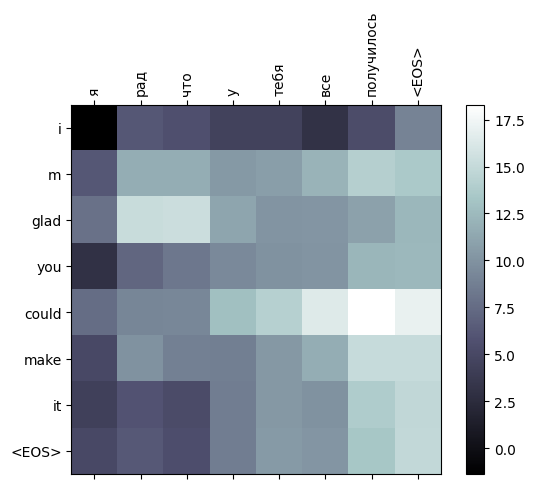

In [ ]:
import matplotlib.pyplot as plt


def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap="bone")
    fig.colorbar(cax)

    # Set up axes
    ax.set_yticks(ax.get_yticks().tolist()[1:-1])
    ax.set_xticks(ax.get_xticks().tolist()[1:-1])

    ax.set_xticklabels(input_sentence.split(" ") + ["<EOS>"], rotation=90)
    ax.set_yticklabels(output_words)
    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(
        encoder, decoder, input_sentence, input_lang, output_lang
    )
    print("input =", input_sentence)
    print("output =", " ".join(output_words))
    showAttention(input_sentence, output_words, attentions[0, : len(output_words), :])


evaluateAndShowAttention("я рад что у тебя все получилось")

**BLEU**

In [ ]:
!pip install -q torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 17.7 MB/s eta 0:00:00


In [ ]:
dnn_for_bleu = [[" ".join(x)] for x in dnn]  # Make a string from separated words
dnn_for_bleu = [
    item for sublist in dnn_for_bleu for item in sublist
]  # Make a list from list of lists

In [ ]:
import torcheval
from torcheval.metrics.functional import bleu_score

bleu = bleu_score(dnn_for_bleu, eng)
print(bleu)

tensor(0.8358)
